<a href="https://colab.research.google.com/github/rayanecardozo/TCCs/blob/main/pix_fraud_detection_Pos_UFES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de Fraude em PIX: Análise Comparativa de Modelos de Machine Learning

Este notebook implementa uma pipeline completa para detecção de fraudes em transações PIX, incluindo:

1. Importação e análise exploratória dos dados
2. Pré-processamento e preparação dos dados
3. Balanceamento usando SMOTE
4. Treinamento e comparação de diferentes modelos (RF, XGBoost, MLP, DNN)
5. Avaliação detalhada do desempenho
6. Interpretação do melhor modelo usando LIME e SHAP

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2d996ba9f2eead6a449405db67c165c52f9de454dfaea0bc3541a2567813961b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from imblearn.over_sampling import SMOTE
import lime
import lime.lime_tabular
import shap
import warnings
warnings.filterwarnings('ignore')

# 1. Importação dos Dados

Vamos carregar os dados do arquivo CSV e fazer uma análise inicial do conjunto de dados.

In [ ]:
# Carregando os dados
df = pd.read_csv('data.csv', sep=";")

# Análise inicial do dataset
print("Dimensões do dataset original:")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

print("\nInformações do dataset:")
df.info()

print("\nVerificando valores nulos por coluna:")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if len(nulos[nulos > 0]) > 0 else "Não há valores nulos no dataset")

print("\nVerificando valores vazios ou em branco por coluna:")
vazios = df.astype(str).apply(lambda x: x.str.strip()).eq('').sum()
print(vazios[vazios > 0] if len(vazios[vazios > 0]) > 0 else "Não há valores vazios no dataset")

print("\nPrimeiras 5 linhas do dataset:")
print(df.head())

print("\nEstatísticas descritivas:")
print(df.describe())
df

Dimensões do dataset original:
Número de linhas: 10000
Número de colunas: 15

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   EndToEndId          10000 non-null  object 
 1   DataHora            10000 non-null  object 
 2   Valor               10000 non-null  float64
 3   Moeda               10000 non-null  object 
 4   Pagador_Nome        10000 non-null  object 
 5   Pagador_CPF_CNPJ    10000 non-null  object 
 6   Pagador_Banco       10000 non-null  object 
 7   Recebedor_Nome      10000 non-null  object 
 8   Recebedor_CPF_CNPJ  10000 non-null  object 
 9   Recebedor_Banco     10000 non-null  object 
 10  ChavePix_Utilizada  10000 non-null  object 
 11  TipoChave           10000 non-null  object 
 12  Descricao           10000 non-null  object 
 13  Status              10000 non-null  object 
 14  A

,EndToEndId,DataHora,Valor,Moeda,Pagador_Nome,Pagador_CPF_CNPJ,Pagador_Banco,Recebedor_Nome,Recebedor_CPF_CNPJ,Recebedor_Banco,ChavePix_Utilizada,TipoChave,Descricao,Status,Anomalia
0,f094cb2c-2a73-463c-b60e-0c57262051e4,2025-06-26 21:07:56,4658.86,BRL,Nathan Cardoso,13.253.967/0001-95,BTG Pactual,Ana Beatriz Ramos,901.361.580-95,Nubank,+559694830-9884,Telefone,Pagamento referente ao serviço 927,Concluída,0
1,f0409769-741f-49bd-811a-3842cc8f54db,2025-06-23 17:47:56,3184.72,BRL,Benjamin Barros,781.515.544-64,Banco do Brasil,Carlos Eduardo Nunes,288.758.607-72,Itaú Unibanco,+552298530-1917,Telefone,Pagamento referente ao serviço 950,Pendente,0
2,c1d22287-d343-4c91-b03d-dbe9a69695b3,2025-06-27 15:58:56,1054.48,BRL,Lorena Cunha,444.922.709-96,Banco Inter,Lívia Silveira,530.827.935-48,Bradesco,c4f4c3c6-4d78-4946-b33e-4a1135711a8a,Chave Aleatória,Pagamento referente ao serviço 173,Pendente,0
3,254423a9-50b7-41b1-a099-e8cf6232bab4,2025-07-15 13:59:56,3564.76,BRL,Sra. Luana Pinto,468.153.904-62,Banco Safra,Helena Pires,827.707.674-51,Caixa Econômica Federal,user421@email.com,E-mail,Pagamento referente ao serviço 560,Estornada,0
4,f1c5e3e7-bc62-4f18-91e3-c8f92aebdd59,2025-06-23 06:19:56,15.16,BRL,João Miguel da Cunha,83.407.726/0001-68,Santander Brasil,Dr. Luiz Felipe Dias,65.245.322/0001-12,C6 Bank,user97@email.com,E-mail,Pagamento referente ao serviço 140,Pendente,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,26217fc5-339c-47ec-85f9-d4b6ebc9eff6,2025-07-10 22:44:57,184.31,BRL,Giovanna da Luz,59.514.705/0001-63,BTG Pactual,Sophia Sales,66.632.973/0001-85,Santander Brasil,253.297.173-10,CPF,Pagamento referente ao serviço 464,Estornada,0
9996,16bbf5b3-76be-427b-ad99-e24d1dc7b7e6,2025-07-28 22:40:57,1657.16,BRL,Srta. Clarice Araújo,66.222.993/0001-75,Banco Safra,Lucas Gabriel da Costa,86.492.137/0001-82,Banco Inter,c78539cd-1516-4111-85bc-9721563743ea,Chave Aleatória,Pagamento referente ao serviço 972,Concluída,0
9997,f09e786d-cddc-4214-a6b0-0ee650f12580,2025-08-02 10:51:57,3344.76,BRL,Luiz Felipe Moreira,87.717.116/0001-65,Nubank,Stella Moraes,290.357.152-63,C6 Bank,user587@email.com,E-mail,Pagamento referente ao serviço 388,Concluída,0
9998,c31e9e81-e67f-4fe2-9ff6-809321eda5ef,2025-07-05 06:24:57,3112.38,BRL,Bianca Monteiro,338.752.120-74,Banco Safra,Sra. Sophie Alves,38.765.466/0001-84,Bradesco,164.603.672-24,CPF,Pagamento referente ao serviço 159,Concluída,0


# 2. Análise Exploratória de Dados (EDA)

Vamos realizar uma análise exploratória para entender melhor a distribuição dos dados e a relação entre as variáveis.


ATENÇÃO: As seguintes linhas foram removidas por data inválida:
                 DataHora  Rotulo
136   2025-02-30 25:61:00       1
758   2025-02-30 25:61:00       1
2389  2025-02-30 25:61:00       1
3018  2025-02-30 25:61:00       1
3064  2025-02-30 25:61:00       1
3170  2025-02-30 25:61:00       1
3482  2025-02-30 25:61:00       1
3586  2025-02-30 25:61:00       1
3707  2025-02-30 25:61:00       1
3999  2025-02-30 25:61:00       1
4384  2025-02-30 25:61:00       1
4672  2025-02-30 25:61:00       1
4833  2025-02-30 25:61:00       1
5153  2025-02-30 25:61:00       1
5999  2025-02-30 25:61:00       1
6446  2025-02-30 25:61:00       1
6687  2025-02-30 25:61:00       1
6905  2025-02-30 25:61:00       1
7042  2025-02-30 25:61:00       1
7232  2025-02-30 25:61:00       1
7942  2025-02-30 25:61:00       1
8011  2025-02-30 25:61:00       1
8871  2025-02-30 25:61:00       1
9777  2025-02-30 25:61:00       1
Total removido: 24 (Fraudes: 24)


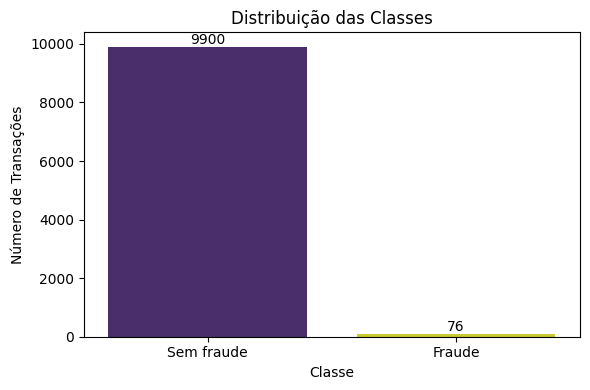

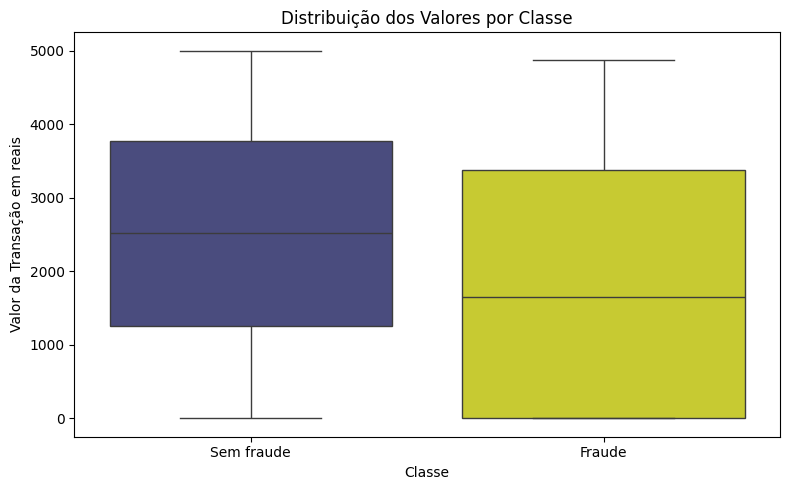

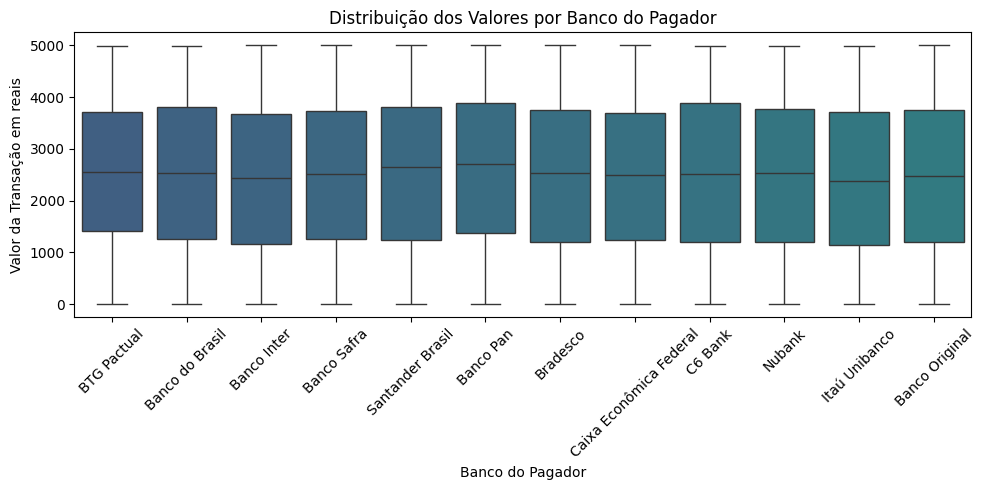

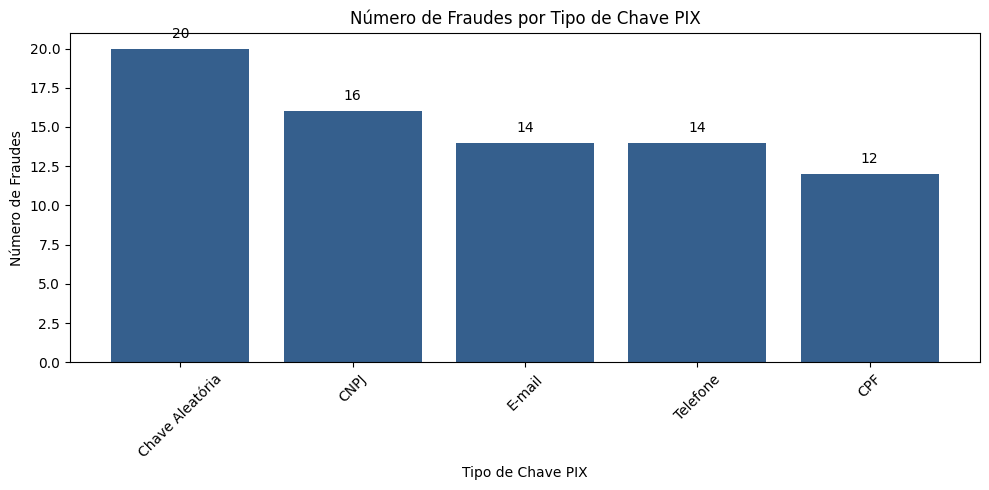

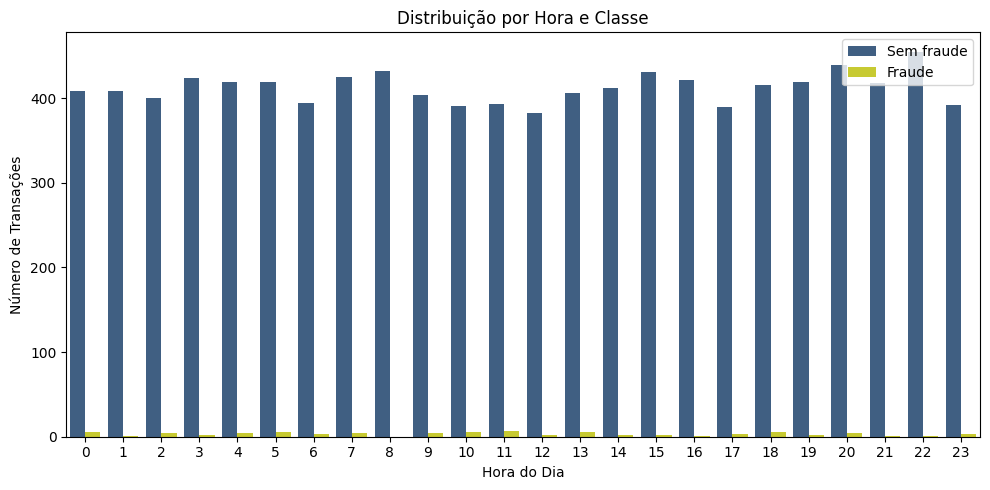

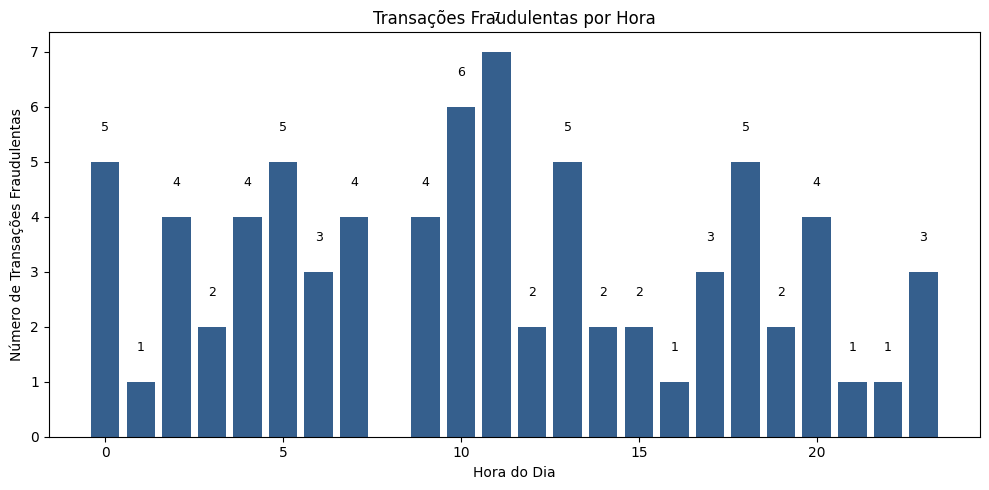

<Figure size 1000x500 with 0 Axes>

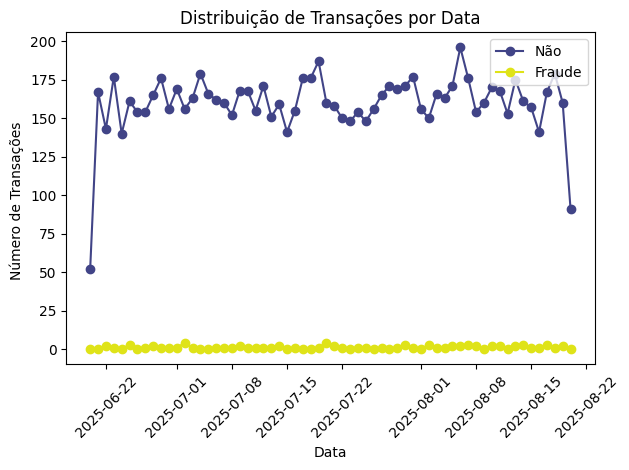

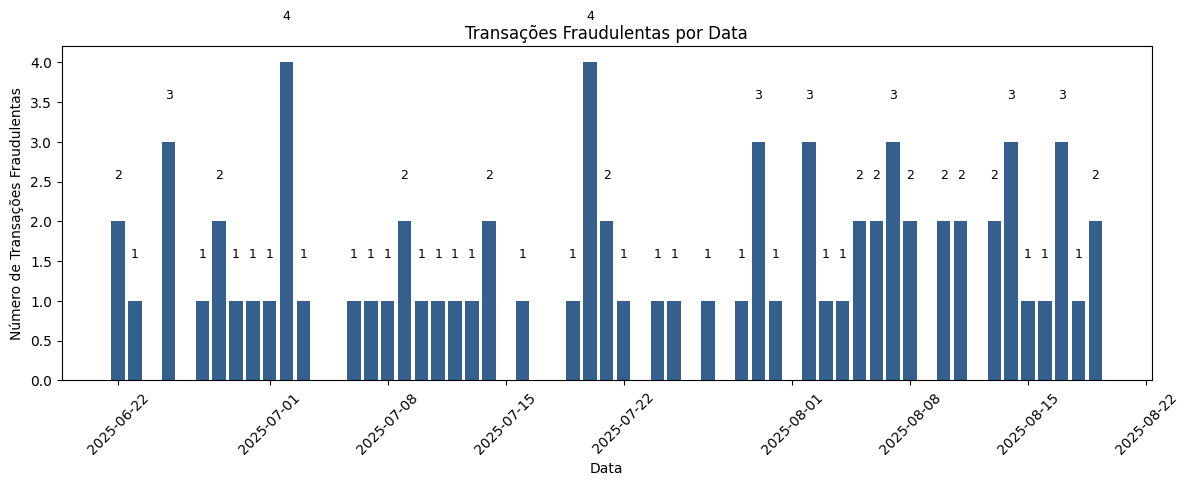

In [ ]:
# 2. Análise Exploratória de Dados (EDA)
from matplotlib.cm import viridis
import matplotlib.colors as mcolors

# Renomear coluna 'Anomalia' para 'Rotulo' se existir
if 'Anomalia' in df.columns:
    df = df.rename(columns={'Anomalia': 'Rotulo'})

# Evidenciar datas removidas por erro de conversão e se eram fraudes
datas_invalidas = None
if 'DataHora' in df.columns:
    # Salvar linhas com datas inválidas antes de converter
    df_temp = pd.read_csv('data.csv', sep=';')
    if 'Anomalia' in df_temp.columns:
        df_temp = df_temp.rename(columns={'Anomalia': 'Rotulo'})
    datas_invalidas = df_temp[pd.to_datetime(df_temp['DataHora'], errors='coerce', format='mixed', dayfirst=True).isna()]
    if not datas_invalidas.empty:
        print('\nATENÇÃO: As seguintes linhas foram removidas por data inválida:')
        print(datas_invalidas[['DataHora', 'Rotulo']])
        print(f"Total removido: {len(datas_invalidas)} (Fraudes: {datas_invalidas['Rotulo'].sum()})")

# Garantir que a coluna 'Hora' existe, lidando com datas inválidas
import warnings
warnings.filterwarnings('ignore')
if 'DataHora' in df.columns and 'Hora' not in df.columns:
    # Tenta converter datas, inferindo formato e ignorando erros
    df['DataHora'] = pd.to_datetime(df['DataHora'], errors='coerce', format='mixed', dayfirst=True)
    # Remove linhas com datas inválidas
    df = df.dropna(subset=['DataHora'])
    df['Hora'] = df['DataHora'].dt.hour
    df['Data'] = df['DataHora'].dt.date

# 1. Distribuição das classes (Normal vs Fraude)
# Verde escuro para ambas as barras
plt.figure(figsize=(6, 4))
sns.countplot(x='Rotulo', data=df, palette=[viridis(0.1), viridis(0.95)])
plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Número de Transações')
plt.xticks([0, 1], ['Sem fraude', 'Fraude'])
for i, v in enumerate(df['Rotulo'].value_counts().sort_index()):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# 2. Distribuição dos valores das transações por classe
plt.figure(figsize=(8, 5))
sns.boxplot(x='Rotulo', y='Valor', data=df, palette=[viridis(0.2), viridis(0.95)])
plt.title('Distribuição dos Valores por Classe')
plt.xlabel('Classe')
plt.ylabel('Valor da Transação em reais')
plt.xticks([0, 1], ['Sem fraude', 'Fraude'])
plt.tight_layout()
plt.show()

# 3. Distribuição dos valores das transações por banco do pagador (paleta viridis, tons escuros)
plt.figure(figsize=(10, 5))
bancos = df['Pagador_Banco'].unique()
cores_bancos = [viridis(0.3 + 0.15*i/max(len(bancos)-1,1)) for i in range(len(bancos))]
sns.boxplot(x='Pagador_Banco', y='Valor', data=df, palette=cores_bancos)
plt.title('Distribuição dos Valores por Banco do Pagador')
plt.xlabel('Banco do Pagador')
plt.ylabel('Valor da Transação em reais')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Distribuição por tipo de chave PIX (número de fraudes por tipo)
plt.figure(figsize=(10, 5))
fraudes_por_tipo = df[df['Rotulo'] == 1]['TipoChave'].value_counts()
# Verde escuro para fraudes: viridis(0.95)
plt.bar(fraudes_por_tipo.index, fraudes_por_tipo.values, color=viridis(0.3))
plt.title('Número de Fraudes por Tipo de Chave PIX')
plt.xlabel('Tipo de Chave PIX')
plt.ylabel('Número de Fraudes')
for i, v in enumerate(fraudes_por_tipo.values):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Distribuição das transações por hora e classe
if 'Hora' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(x='Hora', hue='Rotulo', data=df, palette=[viridis(0.3), viridis(0.95)])
    plt.title('Distribuição por Hora e Classe')
    plt.xlabel('Hora do Dia')
    plt.ylabel('Número de Transações')
    plt.legend(['Sem fraude', 'Fraude'], loc='upper right')
    plt.tight_layout()
    plt.show()

    # 5b. Distribuição das transações fraudulentas por hora
    plt.figure(figsize=(10, 5))
    fraude_por_hora = df[df['Rotulo'] == 1].groupby('Hora').size()
# Verde escuro para fraudes: viridis(0.95)
    plt.bar(fraude_por_hora.index, fraude_por_hora.values, color=viridis(0.3))
    plt.title('Transações Fraudulentas por Hora')
    plt.xlabel('Hora do Dia')
    plt.ylabel('Número de Transações Fraudulentas')
    for i, v in enumerate(fraude_por_hora.values):
        plt.text(fraude_por_hora.index[i], v + 0.5, str(v), ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

# 6. Distribuição por data
plt.figure(figsize=(10, 5))
daily_fraud = df.groupby(['Data', 'Rotulo']).size().unstack(fill_value=0)
daily_fraud.plot(kind='line', marker='o', color=[viridis(0.2), viridis(0.95)])
plt.title('Distribuição de Transações por Data')
plt.xlabel('Data')
plt.ylabel('Número de Transações ')
plt.legend(['Não', 'Fraude'], loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6b. Transações fraudulentas por data (adicional)
plt.figure(figsize=(12, 5))
fraude_por_data = df[df['Rotulo'] == 1].groupby('Data').size()
# Verde escuro para fraudes: viridis(0.95)
plt.bar(fraude_por_data.index, fraude_por_data.values, color=viridis(0.3))
plt.title('Transações Fraudulentas por Data')
plt.xlabel('Data')
plt.ylabel('Número de Transações Fraudulentas')
plt.xticks(rotation=45)
for i, v in enumerate(fraude_por_data.values):
    plt.text(fraude_por_data.index[i], v + 0.5, str(v), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


Visualizando Matriz de Correlação


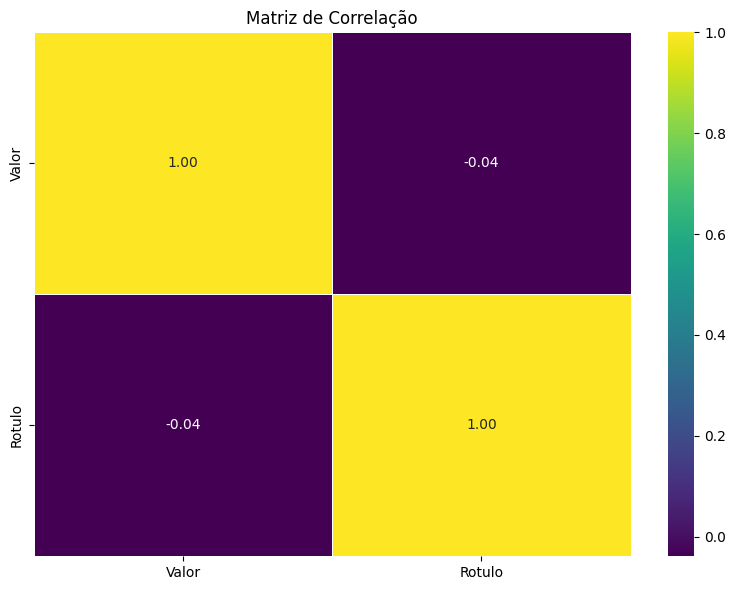

In [ ]:
# Calcular a matriz de correlação
# Usar df que contém as features numéricas após a criação da coluna 'Hora' na célula anterior de EDA
# Garantir que df existe e é um DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("\nVisualizando Matriz de Correlação")
try:
    if 'df' in locals() and isinstance(df, pd.DataFrame):
        # Selecionar apenas colunas numéricas presentes em 'df' neste ponto
        # Assumindo que 'Valor' e 'Hora' são as principais numéricas após a célula anterior
        numeric_cols_eda = df.select_dtypes(include=['int64', 'float64']).columns

        # Garantir que há colunas numéricas para calcular a correlação
        if not numeric_cols_eda.empty:
             # Calcular correlação apenas para colunas numéricas
            correlation_matrix_eda = df[numeric_cols_eda].corr()

            # Plotar o heatmap da matriz de correlação
            plt.figure(figsize=(8, 6)) # Tamanho menor para menos features
            # Usar annot=True se houver poucas features, senão False
            annot_setting = True if len(numeric_cols_eda) <= 10 else False
            sns.heatmap(correlation_matrix_eda, cmap='viridis', annot=annot_setting, fmt=".2f", linewidths=.5)
            plt.title('Matriz de Correlação')
            plt.tight_layout()
            plt.show()

            # Opcional: Identificar pares com alta correlação (menos relevante com poucas features)
            # high_corr_threshold = 0.7 # Manter ou ajustar
            # ... (código para identificar pares com alta correlação, se necessário)
            # print("\nPares de features com alta correlação (> 0.7 ou < -0.7):")
            # ...
            # else:
            # print("\nNão foram encontrados pares de features com alta correlação (> 0.7 ou < -0.7).")

        else:
             print("Não há colunas numéricas em 'df' neste ponto para calcular a correlação.")


    else:
        print("Variável 'df' não encontrada ou não é um DataFrame. Não foi possível gerar a matriz de correlação.")

except Exception as e:
    print(f"Erro ao gerar matriz de correlação: {e}")

# Remover o código de matriz de confusão e curvas ROC que foi movido para a seção de avaliação
# (Este código foi incluído aqui temporariamente na solicitação anterior, mas seu local correto é na avaliação)

# 3. Pré-processamento dos Dados

Vamos realizar o pré-processamento dos dados, incluindo:
1. Tratamento de valores ausentes
2. Normalização das features
3. Preparação para o treinamento

In [ ]:
# Tamanho do dataset antes do pré-processamento
print("Dimensões antes do pré-processamento:")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

# Convertendo DataHora para Unix Epoch Timestamp
print("Convertendo 'DataHora' para Unix Epoch Timestamp...")

# 1. Converte a coluna 'DataHora' para o formato datetime
#    Usar 'errors='coerce'' é FUNDAMENTAL para tratar dados inválidos (como "25:61:00")
df['DataHora'] = pd.to_datetime(df['DataHora'], errors='coerce')

# 2. Remove as linhas onde a conversão falhou (datas/horas inválidas)
#    (Esta etapa é crucial para evitar erros)
df.dropna(subset=['DataHora'], inplace=True)

# 3. Conversão para Unix Epoch Timestamp (em segundos)
#    O .astype(np.int64) converte o datetime para nanosegundos.
#    Dividimos por 1,000,000,000 (10**9) para obter os segundos.
df['Timestamp_Unix'] = (df['DataHora'].astype(np.int64) // 10**9)

print("Coluna 'Timestamp_Unix' criada com sucesso.")

# Removendo colunas desnecessárias
colunas_para_remover = [
    'EndToEndId', 'Moeda', 'Pagador_Nome', 'Pagador_CPF_CNPJ',
    'Recebedor_Nome', 'Recebedor_CPF_CNPJ', 'ChavePix_Utilizada', 'Descricao', 'DataHora', 'Data', 'Hora',

]
df_processed = df.drop(columns=colunas_para_remover)

print("\nDimensões após remover colunas desnecessárias:")
print(f"Número de linhas: {df_processed.shape[0]}")
print(f"Número de colunas: {df_processed.shape[1]}")
print("\nColunas mantidas:")
print(df_processed.columns.tolist())

# Verificando valores ausentes após remoção das colunas
print("\nValores ausentes após remoção das colunas:")
nulos_processed = df_processed.isnull().sum()
print(nulos_processed[nulos_processed > 0] if len(nulos_processed[nulos_processed > 0]) > 0 else "Não há valores nulos")

# Identificando colunas categóricas para codificação
colunas_categoricas = ['Pagador_Banco', 'Recebedor_Banco', 'TipoChave', 'Status']

# Criando dummies para as variáveis categóricas
df_dummies = pd.get_dummies(df_processed, columns=colunas_categoricas, drop_first=True)

print("\nDimensões após criação das variáveis dummy:")
print(f"Número de linhas: {df_dummies.shape[0]}")
print(f"Número de colunas: {df_dummies.shape[1]}")

# Verificando valores ausentes após criação das dummies
print("\nValores ausentes após criação das dummies:")
nulos_dummies = df_dummies.isnull().sum()
print(nulos_dummies[nulos_dummies > 0] if len(nulos_dummies[nulos_dummies > 0]) > 0 else "Não há valores nulos")

# Separando features e target (usando 'Rotulo' em vez de 'Class')
X = df_dummies.drop('Rotulo', axis=1)
y = df_dummies['Rotulo']

# Identificando colunas numéricas para normalização
numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns

# Normalização apenas das features numéricas
scaler = StandardScaler()
X[numeric_columns] = scaler.fit_transform(X[numeric_columns])
X_scaled = X

print("\nDimensões finais após todo o pré-processamento:")
print(f"X_scaled: {X_scaled.shape}")
print(f"y: {y.shape}")

# Verificando os resultados da normalização
print("\nEstatísticas das features normalizadas:")
print(X_scaled.describe().round(2))

# Verificando valores ausentes nos dados finais
print("\nValores ausentes nos dados finais:")
nulos_finais = X_scaled.isnull().sum()
print(nulos_finais[nulos_finais > 0] if len(nulos_finais[nulos_finais > 0]) > 0 else "Não há valores nulos")

Dimensões antes do pré-processamento:
Número de linhas: 9976
Número de colunas: 17
Convertendo 'DataHora' para Unix Epoch Timestamp...
Coluna 'Timestamp_Unix' criada com sucesso.

Dimensões após remover colunas desnecessárias:
Número de linhas: 9976
Número de colunas: 7

Colunas mantidas:
['Valor', 'Pagador_Banco', 'Recebedor_Banco', 'TipoChave', 'Status', 'Rotulo', 'Timestamp_Unix']

Valores ausentes após remoção das colunas:
Não há valores nulos

Dimensões após criação das variáveis dummy:
Número de linhas: 9976
Número de colunas: 32

Valores ausentes após criação das dummies:
Não há valores nulos

Dimensões finais após todo o pré-processamento:
X_scaled: (9976, 31)
y: (9976,)

Estatísticas das features normalizadas:
         Valor  Timestamp_Unix
count  9976.00         9976.00
mean     -0.00           -0.00
std       1.00            1.00
min      -1.72           -1.74
25%      -0.87           -0.87
50%       0.01           -0.00
75%       0.86            0.88
max       1.71         

# 4. Divisão dos Dados em Treino e Teste

Vamos dividir os dados em conjuntos de treino e teste, mantendo a proporção das classes.

In [ ]:
# Divisão dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensões dos conjuntos:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

# Verificando a distribuição das classes nos conjuntos de treino e teste
print("\nDistribuição das classes no conjunto de treino:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)
print("\nDistribuição das classes no conjunto de teste:")
print(pd.Series(y_test).value_counts(normalize=True) * 100)

Dimensões dos conjuntos:
X_train: (7980, 31)
X_test: (1996, 31)
y_train: (7980,)
y_test: (1996,)

Distribuição das classes no conjunto de treino:
Rotulo
0    99.235589
1     0.764411
Name: proportion, dtype: float64

Distribuição das classes no conjunto de teste:
Rotulo
0    99.248497
1     0.751503
Name: proportion, dtype: float64


# 5. Balanceamento dos Dados com SMOTE

Vamos aplicar SMOTE para balancear as classes no conjunto de treino.

Dimensões após o SMOTE:
X_train_balanced: (15838, 31)
y_train_balanced: (15838,)

Distribuição das classes após o SMOTE:
Rotulo
0    50.0
1    50.0
Name: proportion, dtype: float64


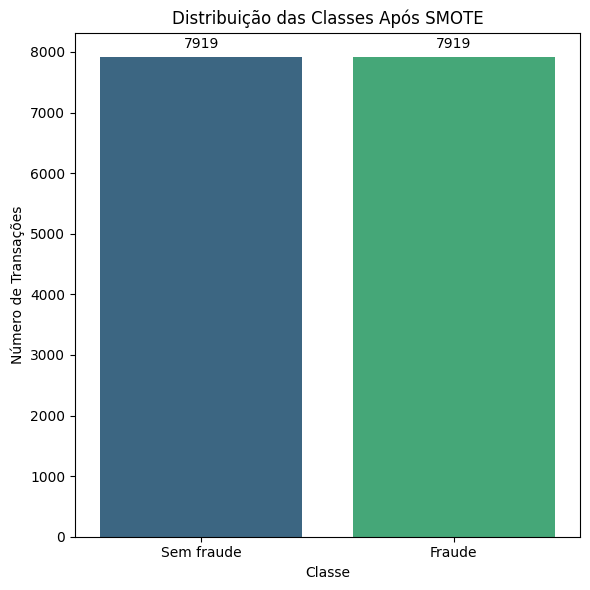

In [ ]:
# Aplicando SMOTE no conjunto de treino
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Dimensões após o SMOTE:")
print(f"X_train_balanced: {X_train_balanced.shape}")
print(f"y_train_balanced: {y_train_balanced.shape}")

print("\nDistribuição das classes após o SMOTE:")
balanced_class_distribution = pd.Series(y_train_balanced).value_counts(normalize=True) * 100
print(balanced_class_distribution)

# Visualizando a distribuição das classes após SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.countplot(x=y_train_balanced, palette='viridis')
plt.title('Distribuição das Classes Após SMOTE')
plt.xlabel('Classe')
plt.ylabel('Número de Transações')
plt.xticks([0, 1], ['Sem fraude', 'Fraude'])
for i, v in enumerate(pd.Series(y_train_balanced).value_counts().sort_index()):
    plt.text(i, v + 100, str(v), ha='center', va='bottom', fontsize=10) # Ajuste o 100 conforme necessário


plt.tight_layout()
plt.show()

# 6. Treinamento dos Modelos

Vamos treinar quatro modelos diferentes:
1. Random Forest
2. XGBoost
3. MLP (Multi-Layer Perceptron)
4. DNN (Deep Neural Network)

In [ ]:
# Função para treinar e avaliar os modelos
def train_and_evaluate(model, X_train, X_test, y_train, y_test, model_name):
    # Treinamento
    model.fit(X_train, y_train)

    # Previsões
    y_pred = model.predict(X_test)

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Probabilidades para ROC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    return {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc
    }

# Definindo os modelos
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'DNN': Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
}

# Compilando o modelo DNN
models['DNN'].compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treinando e avaliando cada modelo
results = {}
for name, model in models.items():
    print(f"\nTreinando {name}...")
    if name == 'DNN':
        # Treinamento específico para DNN
        model.fit(X_train_balanced, y_train_balanced,
                 epochs=10, batch_size=32,
                 validation_split=0.2,
                 verbose=0)
        # Avaliação do DNN
        y_pred = (model.predict(X_test) > 0.5).astype(int)
        y_prob = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc
        }
    else:
        results[name] = train_and_evaluate(model, X_train_balanced, X_test,
                                         y_train_balanced, y_test, name)

# Exibindo resultados
for name, metrics in results.items():
    print(f"\nResultados para {name}:")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1-Score: {metrics['f1']:.4f}")
    print(f"AUC-ROC: {metrics['auc']:.4f}")


Treinando Random Forest...

Treinando XGBoost...

Treinando MLP...

Treinando DNN...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Resultados para Random Forest:
Accuracy: 0.9965
Precision: 0.8333
Recall: 0.6667
F1-Score: 0.7407
AUC-ROC: 0.8414

Resultados para XGBoost:
Accuracy: 0.9930
Precision: 0.5385
Recall: 0.4667
F1-Score: 0.5000
AUC-ROC: 0.8409

Resultados para MLP:
Accuracy: 0.9920
Precision: 0.4286
Recall: 0.2000
F1-Score: 0.2727
AUC-ROC: 0.7556

Resultados para DNN:
Accuracy: 0.9905
Precision: 0.3000
Recall: 0.2000
F1-Score: 0.2400
AUC-ROC: 0.7994


# 6.1 Avaliação dos Modelos

Vamos visualizar as curvas ROC e comparar o desempenho dos modelos.


Matriz de Confusão para cada modelo (Baseline):

Matriz de Confusão para Random Forest:
[[1979    2]
 [   5   10]]


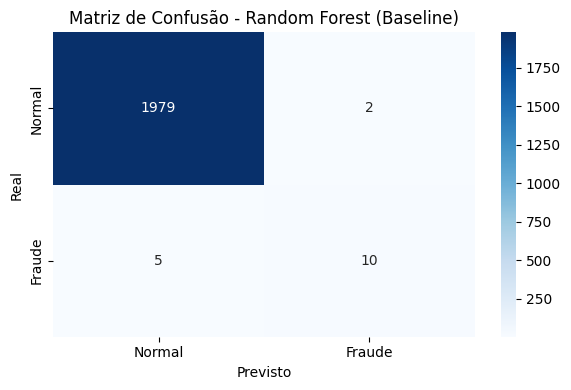


Matriz de Confusão para XGBoost:
[[1975    6]
 [   8    7]]


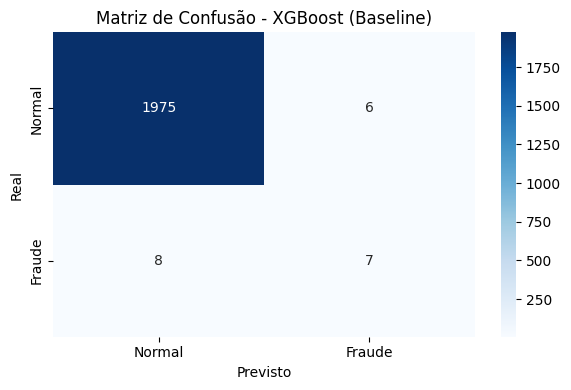


Matriz de Confusão para MLP:
[[1977    4]
 [  12    3]]


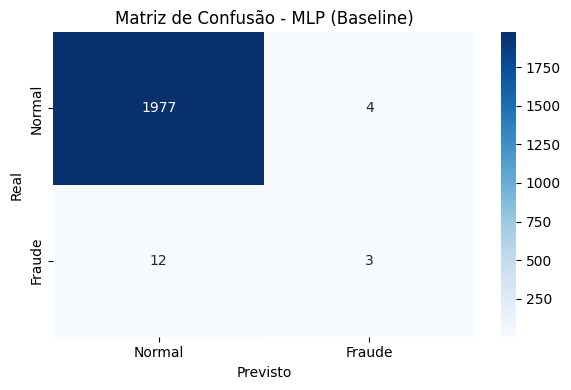

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Matriz de Confusão para DNN:
[[1974    7]
 [  12    3]]


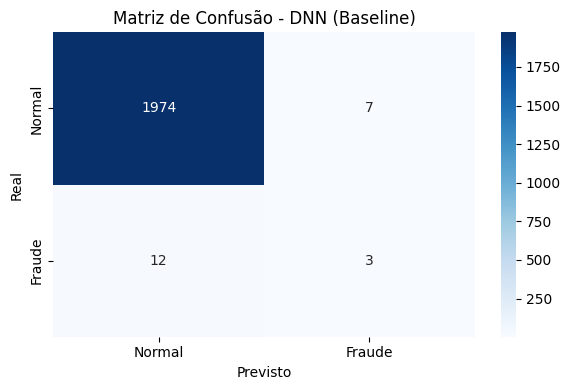

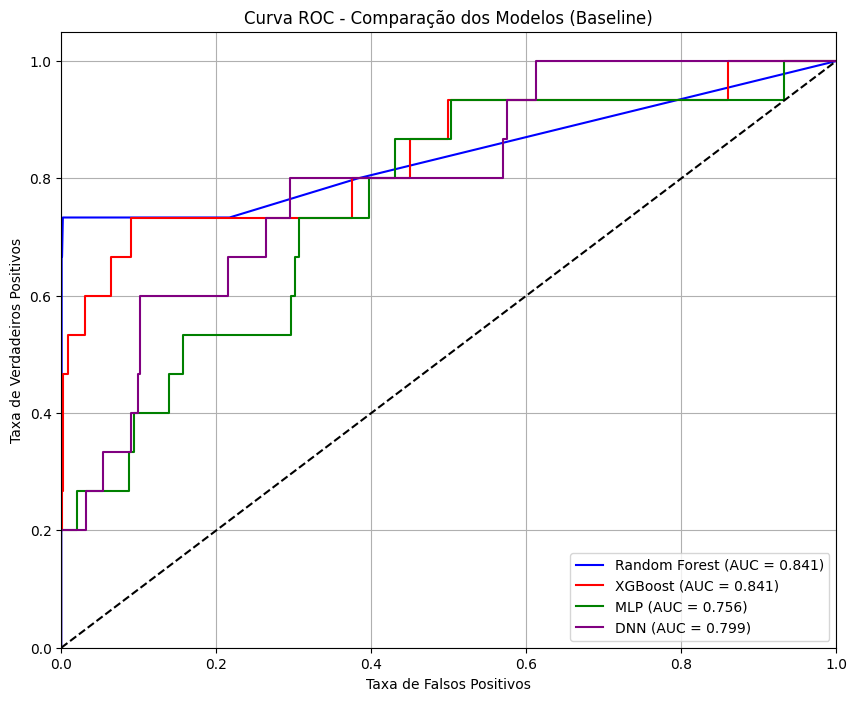


Comparação das métricas entre os modelos (Baseline):
               Acurácia  Precisão  Recall  F1-Score  AUC-ROC
Modelo                                                      
Random Forest    0.9965    0.8333  0.6667    0.7407   0.8414
XGBoost          0.9930    0.5385  0.4667    0.5000   0.8409
MLP              0.9920    0.4286  0.2000    0.2727   0.7556
DNN              0.9905    0.3000  0.2000    0.2400   0.7994

⚠️  NOTA: Estes são os resultados baseline. Execute as células seguintes para ver os modelos otimizados!


In [ ]:
# Add confusion matrix for each model
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("\nMatriz de Confusão para cada modelo (Baseline):")
print("="*50)

for name, metrics in results.items():
    model = metrics['model']
    # Ensure predictions are binary (0 or 1)
    if hasattr(model, 'predict_proba'):
        y_pred = (model.predict_proba(X_test)[:, 1] > 0.5).astype(int)
    elif hasattr(model, 'predict'):
        y_pred = model.predict(X_test)
        # Ensure DNN predictions are binary
        if name == 'DNN':
             y_pred = (y_pred > 0.5).astype(int).flatten()
    else:
        # Fallback if neither predict_proba nor predict are available
        print(f"Could not get predictions for {name} to build confusion matrix.")
        continue

    cm = confusion_matrix(y_test, y_pred)

    print(f"\nMatriz de Confusão para {name}:")
    print(cm)

    # Optional: Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'])
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.title(f'Matriz de Confusão - {name} (Baseline)')
    plt.tight_layout()
    plt.show()

print("\n" + "="*50)


# Plotando as curvas ROC para todos os modelos
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'purple']

for (name, metrics), color in zip(results.items(), colors):
    plt.plot(metrics['fpr'], metrics['tpr'], color=color, label=f'{name} (AUC = {metrics["auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Comparação dos Modelos (Baseline)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Criando um DataFrame com todas as métricas para comparação
metrics_df = pd.DataFrame({
    'Modelo': results.keys(),
    'Acurácia': [metrics['accuracy'] for metrics in results.values()],
    'Precisão': [metrics['precision'] for metrics in results.values()],
    'Recall': [metrics['recall'] for metrics in results.values()],
    'F1-Score': [metrics['f1'] for metrics in results.values()],
    'AUC-ROC': [metrics['auc'] for metrics in results.values()]
})

print("\nComparação das métricas entre os modelos (Baseline):")
print(metrics_df.set_index('Modelo').round(4))
print("\n⚠️  NOTA: Estes são os resultados baseline. Execute as células seguintes para ver os modelos otimizados!")

# 6.2 Feature Engineering Avançado

Vamos criar novas features que podem melhorar a performance dos modelos.

### 6.2.1 Matriz de Correlação Após Feature Engineering

Vamos visualizar a matriz de correlação novamente para incluir as novas features criadas.

In [ ]:
# Feature Engineering Avançado
print("Iniciando Feature Engineering...")

# Voltando ao dataset original para criar novas features
df_features = df.copy()

# 1. Features temporais derivadas
if 'DataHora' in df_features.columns:
    df_features['DataHora'] = pd.to_datetime(df_features['DataHora'], errors='coerce')
    df_features = df_features.dropna(subset=['DataHora'])

    # Features de tempo
    df_features['Hora'] = df_features['DataHora'].dt.hour
    df_features['DiaSemana'] = df_features['DataHora'].dt.dayofweek
    df_features['DiaMes'] = df_features['DataHora'].dt.day
    df_features['FinalSemana'] = (df_features['DiaSemana'] >= 5).astype(int)
    df_features['HorarioComercial'] = ((df_features['Hora'] >= 8) & (df_features['Hora'] <= 18)).astype(int)
    df_features['HorarioNoturno'] = ((df_features['Hora'] >= 22) | (df_features['Hora'] <= 6)).astype(int)

# 2. Features de valor
df_features['Valor_Log'] = np.log1p(df_features['Valor'])
df_features['Valor_Sqrt'] = np.sqrt(df_features['Valor'])

# Quartis de valor
valor_quartis = df_features['Valor'].quantile([0.25, 0.5, 0.75])
df_features['Valor_Quartil'] = pd.cut(df_features['Valor'],
                                      bins=[-np.inf, valor_quartis[0.25], valor_quartis[0.5], valor_quartis[0.75], np.inf],
                                      labels=[1, 2, 3, 4])
df_features['Valor_Quartil'] = df_features['Valor_Quartil'].astype(int)

# 3. Features de interação entre bancos
df_features['Mesmo_Banco'] = (df_features['Pagador_Banco'] == df_features['Recebedor_Banco']).astype(int)

# 4. Features estatísticas por grupos
# Valor médio por banco pagador
valor_medio_banco = df_features.groupby('Pagador_Banco')['Valor'].mean()
df_features['Valor_Media_Banco'] = df_features['Pagador_Banco'].map(valor_medio_banco)
df_features['Valor_Desvio_Media_Banco'] = df_features['Valor'] - df_features['Valor_Media_Banco']

# Taxa de fraude por tipo de chave
taxa_fraude_tipo = df_features.groupby('TipoChave')['Rotulo'].mean()
df_features['Taxa_Fraude_TipoChave'] = df_features['TipoChave'].map(taxa_fraude_tipo)

# 5. Features de frequência
# Contagem de transações por banco pagador
freq_banco = df_features['Pagador_Banco'].value_counts()
df_features['Freq_Banco_Pagador'] = df_features['Pagador_Banco'].map(freq_banco)

# 6. Features de risco
# Valor alto (acima do 95º percentil)
valor_95 = df_features['Valor'].quantile(0.95)
df_features['Valor_Alto'] = (df_features['Valor'] > valor_95).astype(int)

# Timestamp Unix
df_features['Timestamp_Unix'] = (df_features['DataHora'].astype(np.int64) // 10**9)

print("Novas features criadas:")
novas_features = ['Hora', 'DiaSemana', 'DiaMes', 'FinalSemana', 'HorarioComercial', 'HorarioNoturno',
                 'Valor_Log', 'Valor_Sqrt', 'Valor_Quartil', 'Mesmo_Banco', 'Valor_Media_Banco',
                 'Valor_Desvio_Media_Banco', 'Taxa_Fraude_TipoChave', 'Freq_Banco_Pagador', 'Valor_Alto']

for feature in novas_features:
    if feature in df_features.columns:
        print(f"✓ {feature}")

print(f"\nDataset com feature engineering: {df_features.shape}")

Iniciando Feature Engineering...
Novas features criadas:
✓ Hora
✓ DiaSemana
✓ DiaMes
✓ FinalSemana
✓ HorarioComercial
✓ HorarioNoturno
✓ Valor_Log
✓ Valor_Sqrt
✓ Valor_Quartil
✓ Mesmo_Banco
✓ Valor_Media_Banco
✓ Valor_Desvio_Media_Banco
✓ Taxa_Fraude_TipoChave
✓ Freq_Banco_Pagador
✓ Valor_Alto

Dataset com feature engineering: (9976, 32)



Visualizando Matriz de Correlação das Features (Após Feature Engineering):


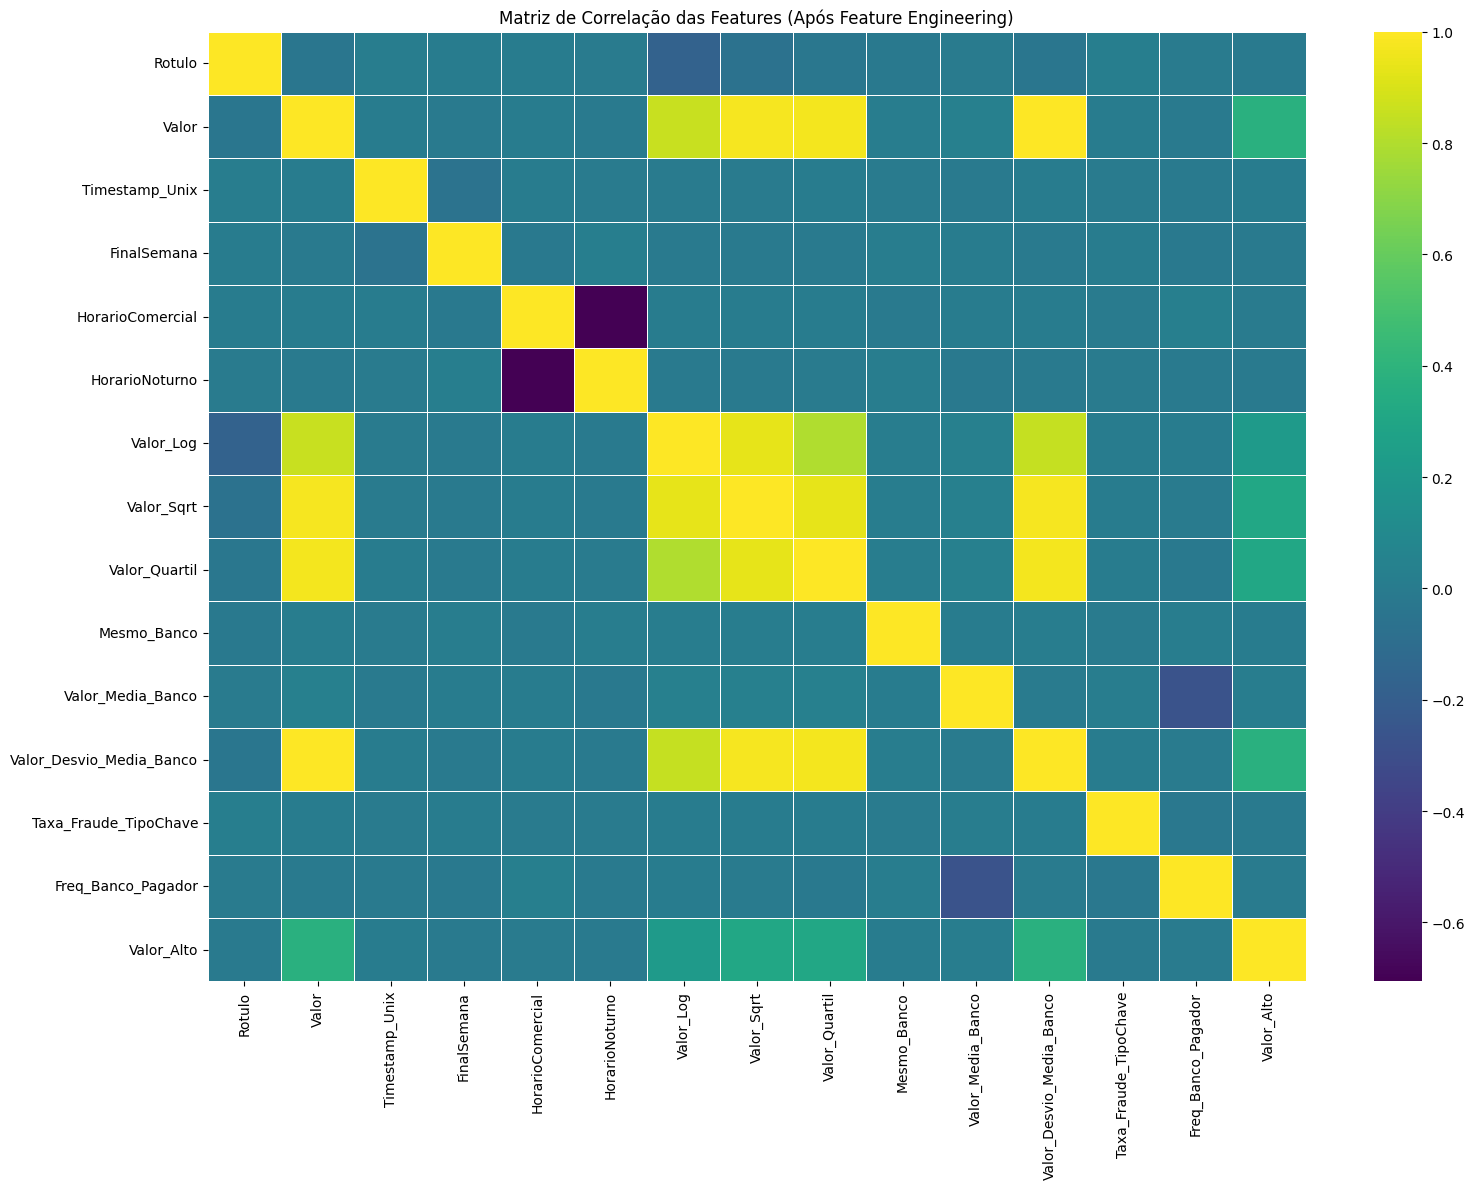


Pares de features com alta correlação (> 0.7 ou < -0.7) após Feature Engineering:
- HorarioNoturno vs HorarioComercial: -0.7055
- Valor_Log vs Valor: 0.8540
- Valor_Sqrt vs Valor: 0.9793
- Valor_Sqrt vs Valor_Log: 0.9338
- Valor_Quartil vs Valor: 0.9685
- Valor_Quartil vs Valor_Log: 0.8000
- Valor_Quartil vs Valor_Sqrt: 0.9399
- Valor_Desvio_Media_Banco vs Valor: 0.9994
- Valor_Desvio_Media_Banco vs Valor_Log: 0.8534
- Valor_Desvio_Media_Banco vs Valor_Sqrt: 0.9787
- Valor_Desvio_Media_Banco vs Valor_Quartil: 0.9679


In [ ]:
# Calcular a matriz de correlação após Feature Engineering
# Usar df_features que contém todas as features (originais e criadas) antes do pré-processamento final
# Precisamos selecionar apenas as colunas numéricas, incluindo o 'Rotulo' agora
numeric_cols_after_fe = df_features.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Mover 'Rotulo' para o início da lista de colunas numéricas, se existir
if 'Rotulo' in numeric_cols_after_fe:
    numeric_cols_list = numeric_cols_after_fe.copy() # Create a copy to avoid modifying the original list during iteration if needed later, although not strictly necessary here
    numeric_cols_list.remove('Rotulo')
    numeric_cols_list.insert(0, 'Rotulo')
    numeric_cols_after_fe = numeric_cols_list


print("\nVisualizando Matriz de Correlação das Features (Após Feature Engineering):")
try:
    # Check if the list is not empty using standard list check
    if numeric_cols_after_fe:
        # Usar a lista de colunas reordenada para calcular a correlação
        correlation_matrix_fe = df_features[numeric_cols_after_fe].corr()

        # Plotar o heatmap
        plt.figure(figsize=(16, 12))
        sns.heatmap(correlation_matrix_fe, cmap='viridis', annot=False, fmt=".2f", linewidths=.5)
        plt.title('Matriz de Correlação das Features (Após Feature Engineering)')
        plt.tight_layout()
        plt.show()

        # Identificar pares com alta correlação
        high_corr_threshold = 0.7
        # Incluir a correlação com o 'Rotulo' na análise de alta correlação, mas apenas os valores absolutos acima do threshold
        # Excluir a correlação de uma feature consigo mesma (diagonal)
        upper_fe = correlation_matrix_fe.where(np.triu(np.ones(correlation_matrix_fe.shape), k=1).astype(bool))

        high_corr_pairs_fe = [(coluna, linha, upper_fe.loc[linha, coluna])
                              for coluna in upper_fe.columns
                              for linha in upper_fe.index if abs(upper_fe.loc[linha, coluna]) > high_corr_threshold and not pd.isna(upper_fe.loc[linha, coluna])]

        if high_corr_pairs_fe:
            print("\nPares de features com alta correlação (> 0.7 ou < -0.7) após Feature Engineering:")
            for feature1, feature2, corr_value in high_corr_pairs_fe:
                print(f"- {feature1} vs {feature2}: {corr_value:.4f}")
        else:
            print("\nNão foram encontrados pares de features com alta correlação (> 0.7 ou < -0.7) após Feature Engineering.")

    else:
        print("Não há colunas numéricas em df_features para calcular a correlação.")

except Exception as e:
    print(f"Erro ao gerar matriz de correlação após Feature Engineering: {e}")

In [ ]:
# Novo pré-processamento com as features criadas
colunas_para_remover_v2 = [
    'EndToEndId', 'Moeda', 'Pagador_Nome', 'Pagador_CPF_CNPJ',
    'Recebedor_Nome', 'Recebedor_CPF_CNPJ', 'ChavePix_Utilizada', 'Descricao', 'DataHora', 'Data'
]

df_processed_v2 = df_features.drop(columns=[col for col in colunas_para_remover_v2 if col in df_features.columns])

# Identificando colunas categóricas
colunas_categoricas_v2 = ['Pagador_Banco', 'Recebedor_Banco', 'TipoChave', 'Status']

# Criando dummies
df_dummies_v2 = pd.get_dummies(df_processed_v2, columns=colunas_categoricas_v2, drop_first=True)

# Separando features e target
X_v2 = df_dummies_v2.drop('Rotulo', axis=1)
y_v2 = df_dummies_v2['Rotulo']

# Normalização
numeric_columns_v2 = X_v2.select_dtypes(include=['int64', 'float64']).columns
scaler_v2 = StandardScaler()
X_v2[numeric_columns_v2] = scaler_v2.fit_transform(X_v2[numeric_columns_v2])

# Divisão dos dados
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

# SMOTE
smote_v2 = SMOTE(random_state=42)
X_train_balanced_v2, y_train_balanced_v2 = smote_v2.fit_resample(X_train_v2, y_train_v2)

print(f"Novo dataset processado: {X_v2.shape}")
print(f"Features após feature engineering: {X_train_balanced_v2.shape[1]}")
print(f"Aumento de features: +{X_train_balanced_v2.shape[1] - X_train_balanced.shape[1]} features")

Novo dataset processado: (9976, 46)
Features após feature engineering: 46
Aumento de features: +15 features


# 7. Otimização de Hiperparâmetros

Vamos usar RandomizedSearchCV para encontrar os melhores hiperparâmetros para cada modelo.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from scipy.stats import randint, uniform
import time

# Definindo grids de hiperparâmetros para cada modelo
param_grids = {
    'Random Forest': {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 20, 30, 40, 50],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    },
    'XGBoost': {
        'n_estimators': randint(100, 500),
        'max_depth': randint(3, 10),
        'learning_rate': uniform(0.01, 0.3),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0, 1)
    },
    'MLP': {
        'hidden_layer_sizes': [(50,), (100,), (100, 50), (150, 100), (200, 100, 50)],
        'activation': ['relu', 'tanh'],
        'alpha': uniform(0.0001, 0.01),
        'learning_rate': ['constant', 'adaptive'],
        'max_iter': [500, 1000],
        'early_stopping': [True],
        'validation_fraction': [0.1]
    }
}

# Modelos base
base_models = {
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    'MLP': MLPClassifier(random_state=42)
}

# Otimização de hiperparâmetros
optimized_models = {}
optimization_results = {}

print("Iniciando otimização de hiperparâmetros...")
print("=" * 50)

for model_name, model in base_models.items():
    print(f"\nOtimizando {model_name}...")
    start_time = time.time()

    # RandomizedSearchCV
    random_search = RandomizedSearchCV(
        model,
        param_grids[model_name],
        n_iter=20,  # Número de combinações a testar
        cv=3,  # 3-fold cross validation
        scoring='f1',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    random_search.fit(X_train_balanced_v2, y_train_balanced_v2)

    optimized_models[model_name] = random_search.best_estimator_
    optimization_results[model_name] = {
        'best_params': random_search.best_params_,
        'best_score': random_search.best_score_,
        'time_taken': time.time() - start_time
    }

    print(f"✓ {model_name} otimizado em {optimization_results[model_name]['time_taken']:.1f}s")
    print(f"  Melhor F1-Score CV: {optimization_results[model_name]['best_score']:.4f}")
    print(f"  Melhores parâmetros: {optimization_results[model_name]['best_params']}")

print("\n" + "=" * 50)
print("Otimização concluída!")

Iniciando otimização de hiperparâmetros...

Otimizando Random Forest...
✓ Random Forest otimizado em 816.5s
  Melhor F1-Score CV: 0.9982
  Melhores parâmetros: {'bootstrap': False, 'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 13, 'n_estimators': 154}

Otimizando XGBoost...
✓ XGBoost otimizado em 53.8s
  Melhor F1-Score CV: 0.9980
  Melhores parâmetros: {'colsample_bytree': np.float64(0.9208787923016158), 'learning_rate': np.float64(0.032365193103931246), 'max_depth': 9, 'n_estimators': 108, 'reg_alpha': np.float64(0.7722447692966574), 'reg_lambda': np.float64(0.1987156815341724), 'subsample': np.float64(0.602208846849441)}

Otimizando MLP...
✓ MLP otimizado em 239.5s
  Melhor F1-Score CV: 0.9971
  Melhores parâmetros: {'activation': 'relu', 'alpha': np.float64(0.00240893825622149), 'early_stopping': True, 'hidden_layer_sizes': (150, 100), 'learning_rate': 'constant', 'max_iter': 1000, 'validation_fraction': 0.1}

Otimização concluída!


# 7.1 Rede Neural Aprimorada

Vamos criar uma DNN mais robusta com técnicas avançadas de regularização e otimização.

In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1_l2

# Função para criar DNN aprimorada
def create_improved_dnn(input_dim, dropout_rate=0.3, l1_reg=0.001, l2_reg=0.001):
    model = Sequential([
        # Primeira camada com normalização
        Dense(256, activation='relu', input_shape=(input_dim,),
              kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg)),
        BatchNormalization(),
        Dropout(dropout_rate),

        # Segunda camada
        Dense(128, activation='relu',
              kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg)),
        BatchNormalization(),
        Dropout(dropout_rate),

        # Terceira camada
        Dense(64, activation='relu',
              kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg)),
        BatchNormalization(),
        Dropout(dropout_rate * 0.5),

        # Quarta camada
        Dense(32, activation='relu',
              kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg)),
        BatchNormalization(),
        Dropout(dropout_rate * 0.5),

        # Camada de saída
        Dense(1, activation='sigmoid')
    ])

    # Compilação com otimizador Adam mais configurado
    optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )

    return model

# Criando a DNN aprimorada
improved_dnn = create_improved_dnn(X_train_balanced_v2.shape[1])

# Callbacks para treinamento
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
]

print("Arquitetura da DNN Aprimorada:")
improved_dnn.summary()

# Treinando a DNN aprimorada
print("\nTreinando DNN Aprimorada...")
history = improved_dnn.fit(
    X_train_balanced_v2, y_train_balanced_v2,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# Adicionando a DNN aprimorada aos modelos otimizados
optimized_models['DNN_Improved'] = improved_dnn

print("✓ DNN Aprimorada treinada com sucesso!")

Arquitetura da DNN Aprimorada:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,217 (223.50 KB)

 Trainable params: 56,257 (219.75 KB)

 Non-trainable params: 960 (3.75 KB)


Treinando DNN Aprimorada...
Epoch 1/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6973 - loss: 4.2314 - precision: 0.5851 - recall: 0.6968 - val_accuracy: 0.8741 - val_loss: 2.6475 - val_precision: 1.0000 - val_recall: 0.8741 - learning_rate: 0.0010
Epoch 2/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9466 - loss: 2.1901 - precision: 0.9312 - recall: 0.9292 - val_accuracy: 0.9110 - val_loss: 1.5006 - val_precision: 1.0000 - val_recall: 0.9110 - learning_rate: 0.0010
Epoch 3/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9671 - loss: 1.1861 - precision: 0.9592 - recall: 0.9526 - val_accuracy: 0.9867 - val_loss: 0.7614 - val_precision: 1.0000 - val_recall: 0.9867 - learning_rate: 0.0010
Epoch 4/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9725 - loss: 0.7002 - precision: 0.9640 - recall: 0.9612 - val_accuracy: 0.9833 - val_loss: 0.5256 - val_precision: 1.0000 - val_recall: 0.9833 - learning_rate: 0.0010
Epoch 5/100
198/198 ━━━━━━━━━━

# 8. Avaliação Aprimorada com Cross-Validation e Ensemble Methods

Vamos avaliar todos os modelos otimizados e criar ensemble methods para melhorar ainda mais o desempenho.

In [ ]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Função aprimorada de avaliação
def evaluate_model_improved(model, X_train, X_test, y_train, y_test, model_name, use_cv=True):
    # Treinamento se necessário
    if model_name != 'DNN_Improved':
        model.fit(X_train, y_train)

    # Previsões
    if model_name == 'DNN_Improved':
        y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
        y_prob = model.predict(X_test).flatten()
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    # Métricas básicas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    results = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc
    }

    # Cross-validation (apenas para modelos sklearn)
    if use_cv and model_name != 'DNN_Improved':
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_f1_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
        results['cv_f1_mean'] = cv_f1_scores.mean()
        results['cv_f1_std'] = cv_f1_scores.std()

    return results

# Avaliando todos os modelos otimizados
print("Avaliando modelos otimizados...")
print("=" * 50)

optimized_results = {}
for name, model in optimized_models.items():
    print(f"\nAvaliando {name}...")
    optimized_results[name] = evaluate_model_improved(
        model, X_train_balanced_v2, X_test_v2, y_train_balanced_v2, y_test_v2, name
    )

    result = optimized_results[name]
    print(f"✓ Accuracy: {result['accuracy']:.4f}")
    print(f"✓ Precision: {result['precision']:.4f}")
    print(f"✓ Recall: {result['recall']:.4f}")
    print(f"✓ F1-Score: {result['f1']:.4f}")
    print(f"✓ AUC-ROC: {result['auc']:.4f}")

    if 'cv_f1_mean' in result:
        print(f"✓ CV F1-Score: {result['cv_f1_mean']:.4f} (±{result['cv_f1_std']:.4f})")

print("\n" + "=" * 50)

Avaliando modelos otimizados...

Avaliando Random Forest...
✓ Accuracy: 0.9980
✓ Precision: 1.0000
✓ Recall: 0.7333
✓ F1-Score: 0.8462
✓ AUC-ROC: 0.8126
✓ CV F1-Score: 0.9982 (±0.0005)

Avaliando XGBoost...
✓ Accuracy: 0.9980
✓ Precision: 1.0000
✓ Recall: 0.7333
✓ F1-Score: 0.8462
✓ AUC-ROC: 0.8789
✓ CV F1-Score: 0.9978 (±0.0009)

Avaliando MLP...
✓ Accuracy: 0.9965
✓ Precision: 0.8333
✓ Recall: 0.6667
✓ F1-Score: 0.7407
✓ AUC-ROC: 0.8632
✓ CV F1-Score: 0.9973 (±0.0004)

Avaliando DNN_Improved...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✓ Accuracy: 0.9980
✓ Precision: 1.0000
✓ Recall: 0.7333
✓ F1-Score: 0.8462
✓ AUC-ROC: 0.8493



###

In [ ]:
# Ensemble Methods
print("Criando Ensemble Methods...")

# Selecionando os 3 melhores modelos (excluindo DNN para ensemble)
sklearn_models = {k: v for k, v in optimized_models.items() if k != 'DNN_Improved'}

# 1. Voting Classifier (Soft Voting)
voting_clf = VotingClassifier(
    estimators=[(name, model) for name, model in sklearn_models.items()],
    voting='soft'
)

print("Treinando Voting Classifier...")
voting_clf.fit(X_train_balanced_v2, y_train_balanced_v2)

# 2. Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=[(name, model) for name, model in sklearn_models.items()],
    final_estimator=LogisticRegression(random_state=42),
    cv=3
)

print("Treinando Stacking Classifier...")
stacking_clf.fit(X_train_balanced_v2, y_train_balanced_v2)

# Adicionando ensembles aos modelos
optimized_models['Voting_Ensemble'] = voting_clf
optimized_models['Stacking_Ensemble'] = stacking_clf

# Avaliando ensembles
print("\nAvaliando Ensemble Methods...")
for name in ['Voting_Ensemble', 'Stacking_Ensemble']:
    optimized_results[name] = evaluate_model_improved(
        optimized_models[name], X_train_balanced_v2, X_test_v2,
        y_train_balanced_v2, y_test_v2, name
    )

    result = optimized_results[name]
    print(f"\n{name}:")
    print(f"✓ F1-Score: {result['f1']:.4f}")
    print(f"✓ AUC-ROC: {result['auc']:.4f}")
    print(f"✓ CV F1-Score: {result['cv_f1_mean']:.4f} (±{result['cv_f1_std']:.4f})")

print("\n✓ Ensemble methods criados e avaliados!")

Criando Ensemble Methods...
Treinando Voting Classifier...
Treinando Stacking Classifier...

Avaliando Ensemble Methods...

Voting_Ensemble:
✓ F1-Score: 0.8462
✓ AUC-ROC: 0.8385
✓ CV F1-Score: 0.9982 (±0.0005)

Stacking_Ensemble:
✓ F1-Score: 0.8462
✓ AUC-ROC: 0.8327
✓ CV F1-Score: 0.9982 (±0.0007)

✓ Ensemble methods criados e avaliados!


# 9. Comparação Final dos Resultados

Vamos comparar todos os modelos aprimorados e identificar o melhor desempenho.

In [ ]:
# Comparação Final dos Resultados
print("COMPARAÇÃO: MODELOS ORIGINAIS vs MODELOS OTIMIZADOS")
print("=" * 70)

# Criando DataFrame comparativo
comparison_data = []

# Resultados originais (se existirem)
if 'results' in locals():
    for name, metrics in results.items():
        comparison_data.append({
            'Modelo': f"{name} (Original)",
            'Versão': 'Original',
            'Acurácia': metrics['accuracy'],
            'Precisão': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1'],
            'AUC-ROC': metrics['auc'],
            'CV F1-Score': 'N/A'
        })

# Resultados otimizados
for name, metrics in optimized_results.items():
    cv_score = f"{metrics.get('cv_f1_mean', 0):.4f}" if 'cv_f1_mean' in metrics else 'N/A'
    comparison_data.append({
        'Modelo': f"{name} (Otimizado)",
        'Versão': 'Otimizado',
        'Acurácia': metrics['accuracy'],
        'Precisão': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1'],
        'AUC-ROC': metrics['auc'],
        'CV F1-Score': cv_score
    })

comparison_df = pd.DataFrame(comparison_data)

# Exibindo tabela comparativa
print("\nTabela Comparativa Completa:")
print(comparison_df.round(4))

# Identificando os melhores modelos
print("\n" + "=" * 70)
print("RANKING DOS MELHORES MODELOS (por AUC-ROC):") # Updated ranking criteria
print("=" * 70)

# Ordenando por AUC-ROC
best_models = comparison_df.sort_values('AUC-ROC', ascending=False).head(5) # Changed sorting to AUC-ROC
for i, (idx, row) in enumerate(best_models.iterrows(), 1):
    print(f"{i}º lugar: {row['Modelo']}")
    print(f"   AUC-ROC: {row['AUC-ROC']:.4f} | F1-Score: {row['F1-Score']:.4f} | CV F1: {row['CV F1-Score']}") # Changed display order
    print()

# Melhoria percentual
if 'results' in locals():
    original_best_auc = max([metrics['auc'] for metrics in results.values()]) # Use AUC-ROC for original best
    optimized_best_auc = max([metrics['auc'] for metrics in optimized_results.values()]) # Use AUC-ROC for optimized best
    improvement_auc = ((optimized_best_auc - original_best_auc) / original_best_auc) * 100 if original_best_auc != 0 else float('inf')

    print(f"MELHORIA GERAL (baseado em AUC-ROC):") # Updated title
    print(f"Melhor AUC-ROC Original: {original_best_auc:.4f}")
    print(f"Melhor AUC-ROC Otimizado: {optimized_best_auc:.4f}")
    print(f"Melhoria: +{improvement_auc:.2f}%")

print("\n" + "=" * 70)

COMPARAÇÃO: MODELOS ORIGINAIS vs MODELOS OTIMIZADOS

Tabela Comparativa Completa:
                          Modelo     Versão  Acurácia  Precisão  Recall  \
0       Random Forest (Original)   Original    0.9965    0.8333  0.6667   
1             XGBoost (Original)   Original    0.9930    0.5385  0.4667   
2                 MLP (Original)   Original    0.9920    0.4286  0.2000   
3                 DNN (Original)   Original    0.9905    0.3000  0.2000   
4      Random Forest (Otimizado)  Otimizado    0.9980    1.0000  0.7333   
5            XGBoost (Otimizado)  Otimizado    0.9980    1.0000  0.7333   
6                MLP (Otimizado)  Otimizado    0.9965    0.8333  0.6667   
7       DNN_Improved (Otimizado)  Otimizado    0.9980    1.0000  0.7333   
8    Voting_Ensemble (Otimizado)  Otimizado    0.9980    1.0000  0.7333   
9  Stacking_Ensemble (Otimizado)  Otimizado    0.9980    1.0000  0.7333   

   F1-Score  AUC-ROC CV F1-Score  
0    0.7407   0.8414         N/A  
1    0.5000   0.8409  

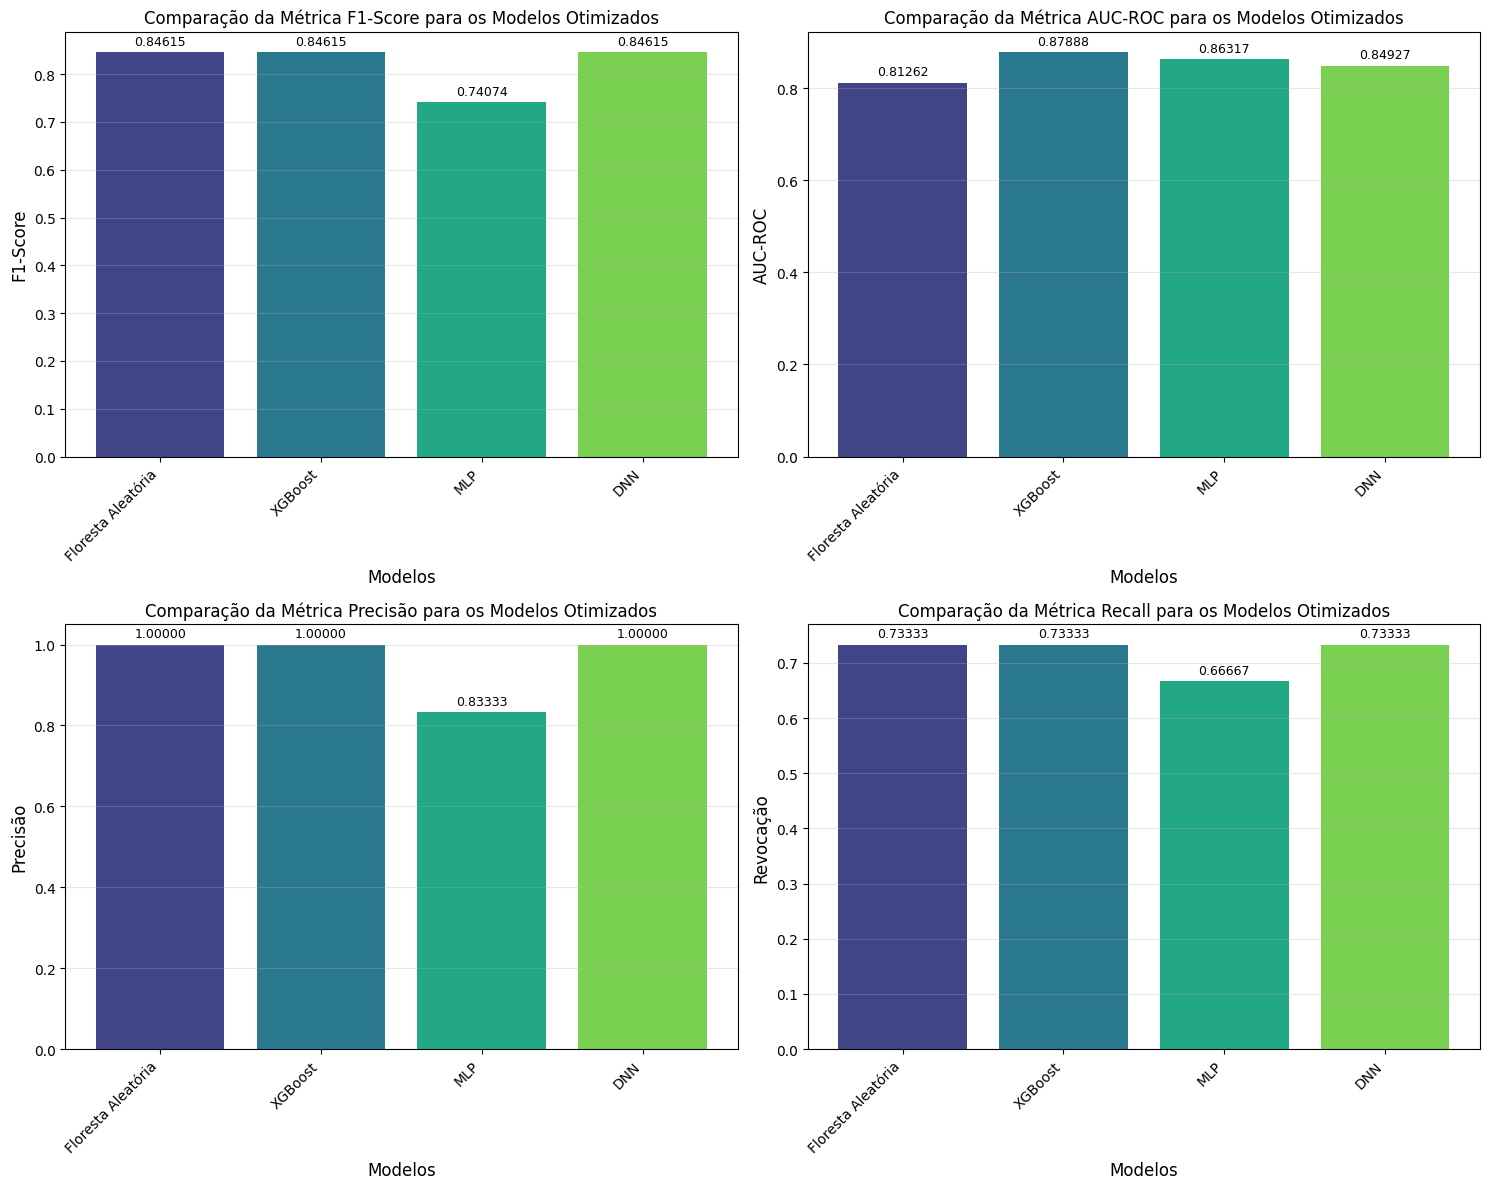

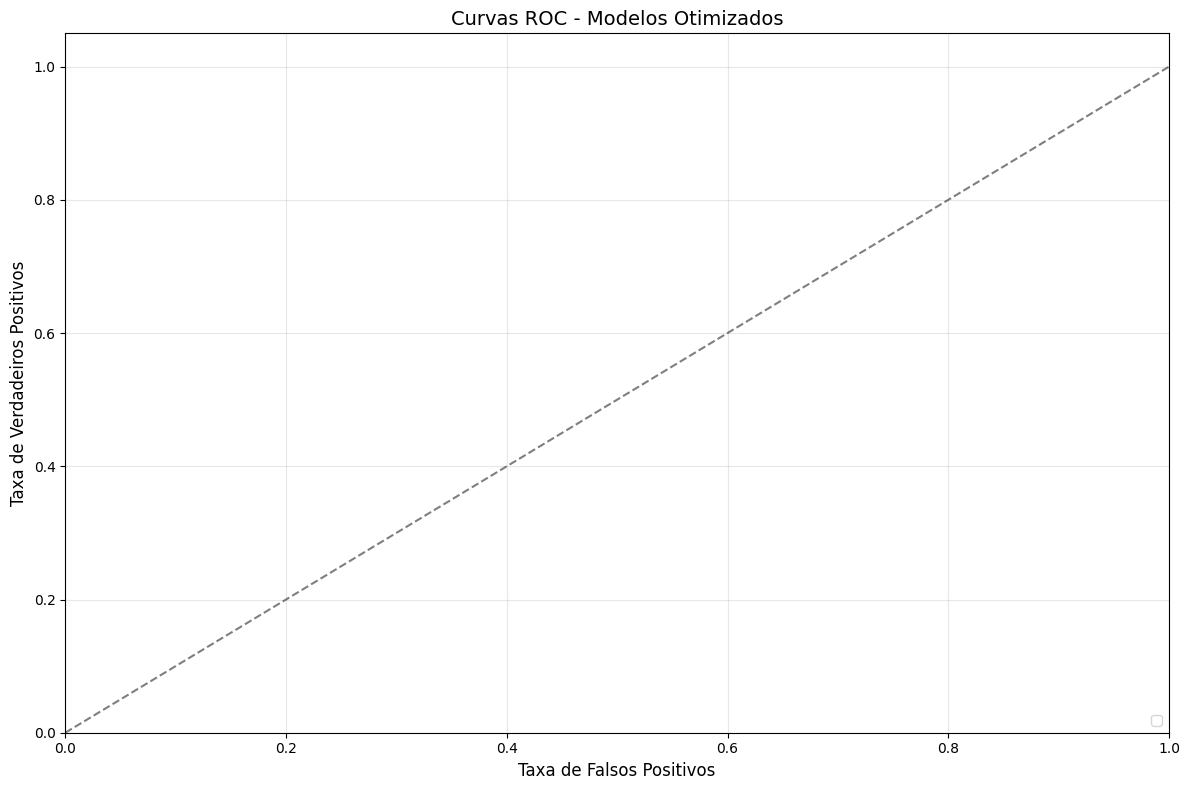

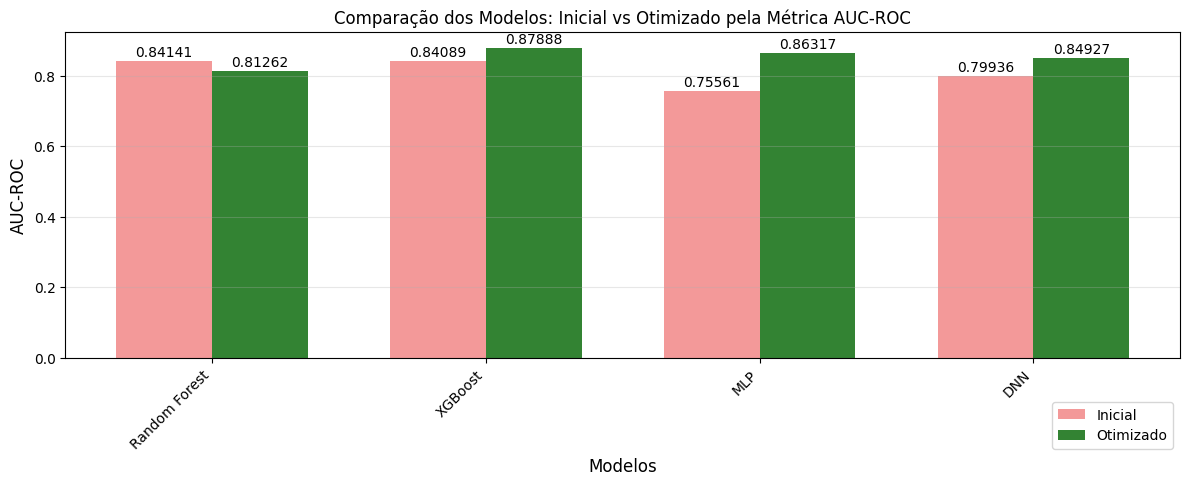

✓ Visualizações comparativas criadas!


In [ ]:
# Visualizações Comparativas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Filtrar e renomear modelos para os gráficos
optimized_only_filtered = comparison_df[
    (comparison_df['Versão'] == 'Otimizado') &
    (~comparison_df['Modelo'].str.contains('Voting_Ensemble')) &
    (~comparison_df['Modelo'].str.contains('Stacking_Ensemble'))
].copy()

# Renomear Random Forest para Floresta Aleatória
optimized_only_filtered['Modelo'] = optimized_only_filtered['Modelo'].replace(
    'Random Forest (Otimizado)', 'Floresta Aleatória (Otimizado)'
)

# Renomear DNN_Improved para DNN
optimized_only_filtered['Modelo'] = optimized_only_filtered['Modelo'].replace(
    'DNN_Improved (Otimizado)', 'DNN (Otimizado)'
)


# 1. Gráfico de barras das métricas principais
metrics_to_plot = ['F1-Score', 'AUC-ROC', 'Precisão', 'Recall'] # Keep 'Recall' here for data selection

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i//2, i%2]
    bars = ax.bar(range(len(optimized_only_filtered)), optimized_only_filtered[metric],
                  color=plt.cm.viridis(np.linspace(0.2, 0.8, len(optimized_only_filtered))))
    ax.set_title(f'Comparação da Métrica {metric} para os Modelos Otimizados')

    # Use 'Revocação' as ylabel if metric is 'Recall'
    if metric == 'Recall':
        ax.set_ylabel('Revocação', fontsize=12)
    else:
        ax.set_ylabel(metric, fontsize=12)

    ax.set_xlabel('Modelos', fontsize=12) # Increased font size
    ax.set_xticks(range(len(optimized_only_filtered)))
    ax.set_xticklabels([name.replace(' (Otimizado)', '') for name in optimized_only_filtered['Modelo']],
                       rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # Adicionando valores nas barras
    for j, bar in enumerate(bars):
        height = bar.get_height()
        # Adjust vertical position of text
        ax.text(bar.get_x() + bar.get_width()/2., height + ax.get_ylim()[1] * 0.01, # Adjusted offset
                f'{height:.5f}', ha='center', va='bottom', fontsize=9) # Changed to .5f

plt.tight_layout() # Apply tight_layout after the first plot loop
plt.show()

# 2. Curvas ROC comparativas (modelos otimizados filtrados)
plt.figure(figsize=(12, 8))
# Gerar cores para o número restante de modelos
colors = plt.cm.viridis(np.linspace(0, 1, len(optimized_only_filtered)))

# Iterar sobre optimized_only_filtered para plotar as curvas ROC
for i, (idx, row) in enumerate(optimized_only_filtered.iterrows()):
    model_name = row['Modelo']
    # Encontrar as métricas originais no dicionário optimized_results
    # Precisamos do nome original para buscar no dicionário optimized_results
    original_model_name = model_name.replace('Floresta Aleatória (Otimizado)', 'Random Forest (Otimizado)').replace('DNN (Otimizado)', 'DNN_Improved (Otimizado)')

    if original_model_name in optimized_results:
         metrics = optimized_results[original_model_name]
         # Add print to check if fpr and tpr are available
         print(f"Plotting ROC for {model_name}: fpr shape={metrics['fpr'].shape}, tpr shape={metrics['tpr'].shape}")
         plt.plot(metrics['fpr'], metrics['tpr'], color=colors[i], linewidth=2,
                  label=f'{model_name.replace(" (Otimizado)", "")} (AUC = {metrics["auc"]:.3f})')


plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos', fontsize=12) # Increased font size
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=12) # Increased font size
plt.title('Curvas ROC - Modelos Otimizados', fontsize=14)
plt.legend(loc="lower right", fontsize=10) # Reverted legend position
plt.grid(True, alpha=0.3)
plt.tight_layout() # Reverted tight_layout
plt.show()

# 3. Comparação de melhorias (se existirem resultados originais)
if 'results' in locals():
    plt.figure(figsize=(12, 6))

    # Prepare data for comparison using AUC-ROC
    original_auc = [metrics['auc'] for metrics in results.values()]
    original_names = list(results.keys())

    # Find corresponding models in the FILTERED optimized results
    optimized_auc = []
    matched_names = []

    for orig_name in original_names:
        # Search for corresponding model in FILTERED optimized results
        for opt_idx, opt_row in optimized_only_filtered.iterrows():
             opt_name = opt_row['Modelo'].replace(' (Otimizado)', '') # Name without "(Otimizado)"
             # Match with the original name
             if orig_name == 'Random Forest' and opt_name == 'Floresta Aleatória':
                  optimized_auc.append(opt_row['AUC-ROC']) # Use AUC-ROC
                  matched_names.append(orig_name)
                  break # Found match, exit inner loop
             elif orig_name == 'DNN' and opt_name == 'DNN': # Match original DNN with Optimized DNN (renamed)
                   optimized_auc.append(opt_row['AUC-ROC']) # Use AUC-ROC
                   matched_names.append(orig_name)
                   break # Found match, exit inner loop
             elif orig_name == opt_name:
                  optimized_auc.append(opt_row['AUC-ROC']) # Use AUC-ROC
                  matched_names.append(orig_name)
                  break # Found match, exit inner loop

    if optimized_auc:  # If matches found
        x = np.arange(len(matched_names))
        width = 0.35

        plt.bar(x - width/2, [results[name]['auc'] for name in matched_names], # Use AUC-ROC for original
                width, label='Inicial', color='lightcoral', alpha=0.8) # Modified label here
        plt.bar(x + width/2, optimized_auc, # Use AUC-ROC for optimized
                width, label='Otimizado', color='darkgreen', alpha=0.8)

        plt.xlabel('Modelos', fontsize=12) # Increased font size
        plt.ylabel('AUC-ROC', fontsize=12) # Changed ylabel to AUC-ROC
        plt.title('Comparação dos Modelos: Inicial vs Otimizado pela Métrica AUC-ROC') # Changed title
        plt.xticks(x, matched_names, rotation=45, ha='right')
        plt.legend(loc='lower right', bbox_to_anchor=(1, -0.3)) # Adjusted legend position to be near x-axis label
        plt.grid(axis='y', alpha=0.3)

        # Adding values on the bars (using AUC-ROC values)
        for i, (orig, opt) in enumerate(zip([results[name]['auc'] for name in matched_names], optimized_auc)): # Use AUC-ROC values
            plt.text(i - width/2, orig + 0.005, f'{orig:.5f}', ha='center', va='bottom') # Changed to .5f and adjusted offset
            plt.text(i + width/2, opt + 0.005, f'{opt:.5f}', ha='center', va='bottom') # Changed to .5f and adjusted offset


        plt.tight_layout(rect=[0, 0.15, 1, 1]) # Adjust layout to make space for legend below
        plt.show()
    else:
        print("\nNão foram encontrados modelos correspondentes nos resultados otimizados filtrados para comparação de melhorias.")

print("✓ Visualizações comparativas criadas!")

# 10. Resumo das Melhorias Implementadas

Este notebook foi significativamente aprimorado com as seguintes otimizações:

# 12. Interpretação do Melhor Modelo com LIME

Vamos analisar o melhor modelo usando LIME para entender quais features são mais importantes para as previsões.

Melhor modelo otimizado (baseado em AUC): XGBoost

Explicando a previsão para a transação de teste no índice: 6713 (Classe Real: Fraude)


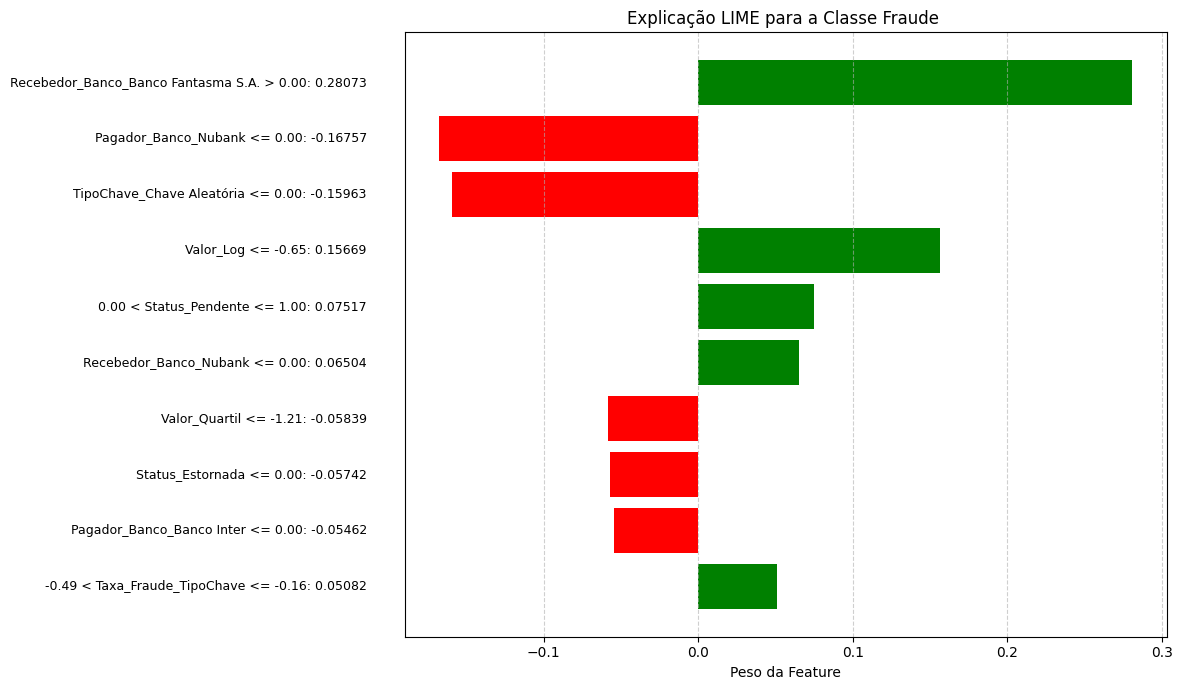

In [ ]:
# Identificando o melhor modelo baseado no F1-Score
# Use optimized_results para pegar o melhor modelo otimizado
best_model_name = None
# Alterando a métrica de seleção para AUC-ROC
best_metric_value = -1
metric_to_compare = 'auc' # Definindo a métrica para comparação

# Encontrar o melhor modelo otimizado pelo AUC-ROC
for name, metrics in optimized_results.items():
    # Garantir que a métrica existe antes de comparar
    if metric_to_compare in metrics:
        if metrics[metric_to_compare] > best_metric_value:
            best_metric_value = metrics[metric_to_compare]
            best_model_name = name

if best_model_name:
    best_model = optimized_models[best_model_name]
    print(f"Melhor modelo otimizado (baseado em {metric_to_compare.upper()}): {best_model_name}")
else:
    print(f"Não foi possível identificar o melhor modelo com base em {metric_to_compare.upper()}")
    # Fallback ou sair se não houver modelos válidos
    # Por segurança, pode ser útil atribuir um modelo padrão se necessário
    # Ex: best_model = list(optimized_models.values())[0] if optimized_models else None
    # return # Ou raise uma exceção

# LIME
# Usar X_test_v2 para LIME, pois ele contém todas as features (originais + engenharia)
# Verificar se best_model foi atribuído antes de usar
if best_model_name and best_model:
    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train_balanced_v2.values, # Usar dados de treino balanceados para o background
        feature_names=X_test_v2.columns.tolist(), # Usar nomes das features de X_test_v2
        class_names=['Normal', 'Fraude'],
        mode='classification'
    )

    # Explicando uma previsão específica com LIME
    # Escolher um índice para analisar (e.g., uma fraude no teste)
    # Primeiro, encontrar um índice de fraude no conjunto de teste original (y_test_v2)
    fraud_indices = y_test_v2[y_test_v2 == 1].index.tolist()

    if fraud_indices:
        idx_to_explain = fraud_indices[0] # Pegar o primeiro índice de fraude encontrado
        print(f"\nExplicando a previsão para a transação de teste no índice: {idx_to_explain} (Classe Real: Fraude)")

        # Usar os dados correspondentes de X_test_v2 para a explicação
        instance_to_explain = X_test_v2.loc[idx_to_explain].values

        # Garantir que a função de previsão do modelo esteja no formato correto para LIME
        if hasattr(best_model, 'predict_proba'):
            predict_fn_lime = best_model.predict_proba
        elif hasattr(best_model, 'predict'):
             # Para modelos que não retornam probabilidade direta (como alguns resultados de DNN ou MLP),
             # precisa garantir que o output seja bidimensional para LIME, mesmo que seja 0 ou 1
             # Para DNN, predict já retorna probabilidades (0 a 1), mas reshape é bom.
             # Para outros, pode ser necessário ajustar dependendo do output.
             # Para a DNN_Improved, model.predict(X_test).flatten() retorna a prob de ser 1.
             # LIME espera [Prob_Classe_0, Prob_Classe_1].
             # Então, para DNN_Improved, podemos criar uma função wrapper
             # Verificar se o modelo é uma instância do modelo DNN aprimorado (ou similar)
             # Usar o nome do modelo otimizado para verificar
             if best_model_name and 'DNN' in best_model_name: # Verifica se o nome do modelo contém 'DNN'
                def predict_fn_dnn_wrapper(x):
                    # x será um array 2D (n_samples, n_features)
                    # predict retorna (n_samples, 1)
                    probs_class_1 = best_model.predict(x).flatten()
                    # Criar array [prob_classe_0, Prob_Classe_1]
                    probs = np.vstack([1 - probs_class_1, probs_class_1]).T
                    return probs
                predict_fn_lime = predict_fn_dnn_wrapper
             else:
                 # Para outros modelos que retornam apenas a classe (0 ou 1)
                 # LIME pode não funcionar bem ou as explicações não serão baseadas na probabilidade.
                 # Vamos tentar usar o predict, mas com ressalvas.
                 # Para classification mode, predict_proba é ideal.
                 print("Aviso: O melhor modelo não tem 'predict_proba'. Usando 'predict' que pode não ser ideal para LIME.")
                 predict_fn_lime = best_model.predict

        try:
            exp = explainer.explain_instance(
                instance_to_explain,
                predict_fn_lime,
                num_features=10 # Mostrar as 10 features mais importantes
            )

            # --- Código do gráfico LIME mais conciso ---
            fig, ax = plt.subplots(figsize=(12, len(exp.as_list()) * 0.5 + 2))

            # Obter a lista de explicações formatada (Feature, Peso)
            explanation_list = exp.as_list()

            # Separar features e pesos
            features = [item[0] for item in explanation_list]
            weights = [item[1] for item in explanation_list]

            # Criar gráfico de barras horizontais
            y_pos = np.arange(len(features))
            bars = ax.barh(y_pos, weights, color=['green' if w > 0 else 'red' for w in weights])

            # Removido o código que adicionava rótulos dos pesos ao lado das barras


            ax.set_yticks([]) # Remover rótulos do eixo Y
            ax.invert_yaxis() # Inverter ordem
            ax.set_xlabel('Peso da Feature')
            ax.set_title(f"Explicação LIME para a Classe Fraude ") #(Índice {idx_to_explain})
            plt.grid(axis='x', linestyle='--', alpha=0.6)

            # Adicionar rótulos das features e seus pesos na lateral esquerda
            x_limit_left = ax.get_xlim()[0]
            x_range = ax.get_xlim()[1] - x_limit_left
            # Ajustar a posição horizontal para aproximar do quadro de exibição
            text_x_pos = x_limit_left - x_range * 0.05 # Reduzir o offset para 5% da largura do gráfico

            for i, (feature, weight) in enumerate(explanation_list):
                # Formatar o rótulo da feature e peso
                feature_label = f"{feature}: {weight:.5f}" # Combinar feature e peso com 5 casas decimais
                plt.text(text_x_pos, i, feature_label,
                         va='center', ha='right', fontsize=9) # Ajustar posição, alinhamento e fontsize

            plt.tight_layout()
            plt.show()
            # --- Fim do código do gráfico LIME ---


        except Exception as e:
            print(f"Erro ao gerar explicação LIME: {e}")
            print("Verifique se a função de predição do modelo está retornando o formato esperado por LIME.")


    else:
        print("\nNenhuma transação fraudulenta encontrada no conjunto de teste para explicar com LIME.")